In [2]:
import os
import numpy as np
import pandas as pd
from skimage import io, transform 
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm

In [3]:
data = pd.read_csv("dataset.csv")


X_features = [] 
y_labels = []   
print(data.head())
print(data.shape)
nb_img_fracture = (data["fractured"]==1).sum()
print(nb_img_fracture)

         image_id  hand  leg  hip  shoulder  mixed  hardware  multiscan  \
0  IMG0000000.jpg     0    1    0         0      0         0          1   
1  IMG0000001.jpg     0    1    0         0      0         0          1   
2  IMG0000002.jpg     0    1    0         0      0         0          1   
3  IMG0000003.jpg     0    1    0         0      0         0          1   
4  IMG0000004.jpg     0    1    0         0      0         0          1   

   fractured  fracture_count  frontal  lateral  oblique  
0          0               0        1        1        0  
1          0               0        1        1        0  
2          0               0        1        1        0  
3          0               0        0        1        1  
4          0               0        0        1        1  
(4083, 13)
717


In [19]:
print("Début du chargement des images (via skimage) et de l'extraction HOG...")
IMAGE_BASE_DIR = "images" 
TARGET_SIZE = (128, 128)
# =====================================================================
# 2. BOUCLE SUR LE DATASET
# =====================================================================
for index, row in tqdm(data.iterrows(), total=data.shape[0], desc="Extraction HOG"):
    image_name = row['image_id']
    is_fractured = row['fractured']
    
    sub_folder = "Fractured" if is_fractured == 1 else "non_Fractured"
        
    image_path = os.path.join(IMAGE_BASE_DIR, sub_folder, image_name)
    
    if os.path.exists(image_path):
        try:

            img = io.imread(image_path, as_gray=True)
            
            img_resized = transform.resize(img, TARGET_SIZE, anti_aliasing=True)
            
            features = hog(img_resized, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=False)
            
            X_features.append(features)
            y_labels.append(is_fractured)
            
        except Exception as e:
            print(f"Erreur lors de la lecture de l'image {image_name} : {e}")
    else:
        print(f"Attention : L'image {image_path} est introuvable.")

X_features = np.array(X_features)
y_labels = np.array(y_labels)

print(f"\nChargement terminé ! {len(X_features)} images chargées.")



Début du chargement des images (via skimage) et de l'extraction HOG...


Extraction HOG:  96%|█████████▌| 3927/4083 [13:04<00:04, 35.78it/s]  

Erreur lors de la lecture de l'image IMG0004028.jpg : image file is truncated (20 bytes not processed)
Erreur lors de la lecture de l'image IMG0004029.jpg : image file is truncated (23 bytes not processed)
Erreur lors de la lecture de l'image IMG0004036.jpg : image file is truncated (13 bytes not processed)


Extraction HOG:  97%|█████████▋| 3944/4083 [13:04<00:03, 35.52it/s]

Erreur lors de la lecture de l'image IMG0004070.jpg : image file is truncated (2 bytes not processed)
Erreur lors de la lecture de l'image IMG0004073.jpg : image file is truncated (6 bytes not processed)
Erreur lors de la lecture de l'image IMG0004076.jpg : image file is truncated (0 bytes not processed)
Erreur lors de la lecture de l'image IMG0004079.jpg : image file is truncated (27 bytes not processed)


...

Erreur lors de la lecture de l'image IMG0004308.jpg : image file is truncated (42 bytes not processed)


Extraction HOG: 100%|█████████▉| 4074/4083 [13:08<00:00, 36.28it/s]

Erreur lors de la lecture de l'image IMG0004347.jpg : image file is truncated (42 bytes not processed)


Extraction HOG: 100%|██████████| 4083/4083 [13:08<00:00,  5.18it/s]


Chargement terminé ! 4024 images chargées.


In [11]:
# =====================================================================
# 3. ENTRAÎNEMENT ET ÉVALUATION DU SVM
# =====================================================================
if len(X_features) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
    )
    
    print("\nEntraînement du modèle SVM...")
    svm_model = SVC(kernel='poly', C=1.0,class_weight='balanced', random_state=42)
    svm_model.fit(X_train, y_train)
    
    y_pred = svm_model.predict(X_test)
    print("Evaluation du modèle")
    print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("\nRapport de classification détaillé :")
    print(classification_report(y_test, y_pred, target_names=['Sain', 'Fracture']))


Entraînement du modèle SVM...
Evaluation du modèle
Précision globale (Accuracy) : 85.47%

Rapport de classification détaillé :
              precision    recall  f1-score   support

        Sain       0.90      0.92      0.91       662
    Fracture       0.60      0.55      0.57       143

    accuracy                           0.85       805
   macro avg       0.75      0.73      0.74       805
weighted avg       0.85      0.85      0.85       805



In [20]:
from sklearn.model_selection import GridSearchCV

base_svm = SVC(kernel='poly', class_weight='balanced', random_state=42)

param_grid = {'degree': [2, 3, 4],'C': [0.1, 1, 10]}

print("Recherche des meilleurs hyperparamètres en cours (Grid Search)...")
grid_search = GridSearchCV(estimator=base_svm, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

grid_search.fit(X_train, y_train)


print("OPTIMISATION TERMINÉE")
print(f"Meilleurs paramètres trouvés : {grid_search.best_params_}")
print(f"Meilleur score de validation (F1-macro) : {grid_search.best_score_ * 100:.2f}%")

best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(X_test)

print("RÉSULTATS DU MEILLEUR SVM SUR LE JEU DE TEST")
print(classification_report(y_test, y_pred, target_names=['Sain', 'Fracture']))

Recherche des meilleurs hyperparamètres en cours (Grid Search)...
OPTIMISATION TERMINÉE
Meilleurs paramètres trouvés : {'C': 1, 'degree': 3}
Meilleur score de validation (F1-macro) : 71.64%
RÉSULTATS DU MEILLEUR SVM SUR LE JEU DE TEST
              precision    recall  f1-score   support

        Sain       0.90      0.92      0.91       662
    Fracture       0.60      0.55      0.57       143

    accuracy                           0.85       805
   macro avg       0.75      0.73      0.74       805
weighted avg       0.85      0.85      0.85       805



In [1]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [5]:
IMAGE_BASE_DIR = "images" 
IMG_SHAPE = (128, 128, 1) 

X_raw_images = []
y_labels = []

print("Début du chargement des images pour le CNN....")
total_rows = len(data)
loaded_count = 0
error_count = 0

for index, row in data.iterrows():
    image_name = row['image_id']
    is_fractured = row['fractured']
    sub_folder = "Fractured" if is_fractured == 1 else "non_Fractured"
    image_path = os.path.join(IMAGE_BASE_DIR, sub_folder, image_name)
    
    if os.path.exists(image_path):
        try:
            img = io.imread(image_path, as_gray=True)
            img_resized = transform.resize(img, (128, 128), anti_aliasing=True)
            
            X_raw_images.append(img_resized)
            y_labels.append(is_fractured)
            loaded_count += 1
        except Exception as e:
            error_count += 1
            pass  
    else:
        error_count += 1

    if index % 100 == 0 or index == total_rows - 1:
        print(f"Progression : {index + 1}/{total_rows} lignes traitées... ({loaded_count} images chargées avec succès)")

print("\n--- Fin du chargement ---")
print(f"-> Total d'images chargées avec succès : {loaded_count}")
print(f"-> Total d'images ignorées (introuvables ou corrompues) : {error_count}")


X_raw_images = np.array(X_raw_images)
y_labels = np.array(y_labels)



X_raw_images = np.expand_dims(X_raw_images, axis=-1)




Début du chargement des images pour le CNN....
Progression : 1/4083 lignes traitées... (1 images chargées avec succès)
Progression : 101/4083 lignes traitées... (101 images chargées avec succès)
Progression : 201/4083 lignes traitées... (201 images chargées avec succès)
Progression : 301/4083 lignes traitées... (301 images chargées avec succès)
Progression : 401/4083 lignes traitées... (401 images chargées avec succès)
Progression : 501/4083 lignes traitées... (501 images chargées avec succès)
Progression : 601/4083 lignes traitées... (601 images chargées avec succès)
Progression : 701/4083 lignes traitées... (701 images chargées avec succès)
Progression : 801/4083 lignes traitées... (801 images chargées avec succès)
Progression : 901/4083 lignes traitées... (901 images chargées avec succès)
Progression : 1001/4083 lignes traitées... (1001 images chargées avec succès)
Progression : 1101/4083 lignes traitées... (1101 images chargées avec succès)
Progression : 1201/4083 lignes traitées..

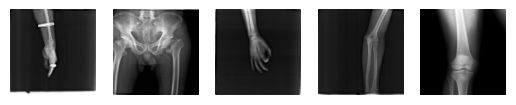

Séparation des données en train/test...
Création des valeurs de test par époque...
Entraînement (X_train) : (3219, 128, 128, 1)
Validation  (X_val)   : (483, 128, 128, 1) 
Test        (X_test)  : (805, 128, 128, 1) 


In [62]:
plt.figure
for i in range(5):
 plt.subplot(1,5,i+1)
 plt.imshow(X_train[i],cmap='gray')
 plt.axis('off')
plt.show()

print("Séparation des données en train/test...")
X_train, X_test, y_train, y_test = train_test_split(
    X_raw_images, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print("Création des valeurs de test par époque...")
X_train_reel, X_val, y_train_reel, y_val_c = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)
print(f"Entraînement (X_train) : {X_train.shape}")
print(f"Validation  (X_val)   : {X_val.shape} ")
print(f"Test        (X_test)  : {X_test.shape} ")

In [66]:
model = models.Sequential([
 
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMG_SHAPE),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', 
              metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])

model.summary() 


C:\Users\Godar\miniconda3\envs\torchnv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)                   │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_31 (MaxPooling2D)      │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_32 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
from tensorflow.keras.callbacks import EarlyStopping
import time 

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"Poids appliqués pour équilibrer les classes : {class_weight_dict}")


early_stopping = EarlyStopping(monitor='val_recall', patience = 5, restore_best_weights=True)

start_time= time.time()

history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val_c),
                    class_weight=class_weight_dict, callbacks=[early_stopping])

end_time = time.time()
temps_app = end_time-start_time


Poids appliqués pour équilibrer les classes : {0: np.float64(0.6085066162570888), 1: np.float64(2.804006968641115)}
Epoch 1/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 17s 145ms/step - accuracy: 0.6300 - loss: 0.6810 - recall: 0.4930 - val_accuracy: 0.7516 - val_loss: 0.6301 - val_recall: 0.5233
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.6803 - loss: 0.6206 - recall: 0.6098 - val_accuracy: 0.5487 - val_loss: 0.6557 - val_recall: 0.8488
Epoch 3/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.7064 - loss: 0.5694 - recall: 0.6916 - val_accuracy: 0.7619 - val_loss: 0.5215 - val_recall: 0.7093
Epoch 4/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.7130 - loss: 0.5574 - recall: 0.7143 - val_accuracy: 0.8385 - val_loss: 0.4220 - val_recall: 0.6860
Epoch 5/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.7518 - loss: 0.5167 - recall: 0.7282 - val_accuracy: 0.7930 - val_loss: 0.4490 - val_recall: 0.8140
Epoch 6/15
101/101 ━━━━━━━━━━━━━━━━━━━━

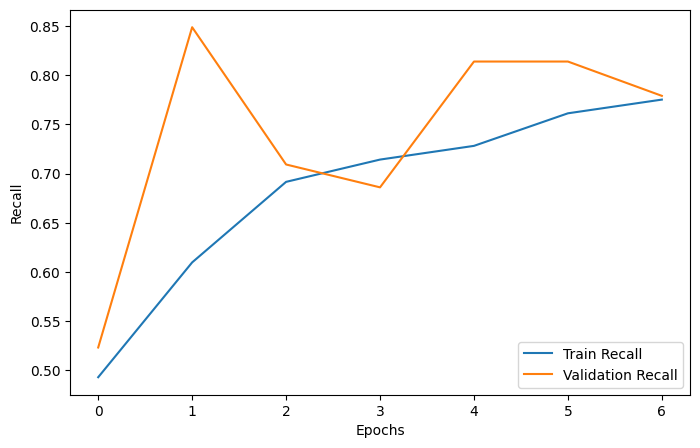

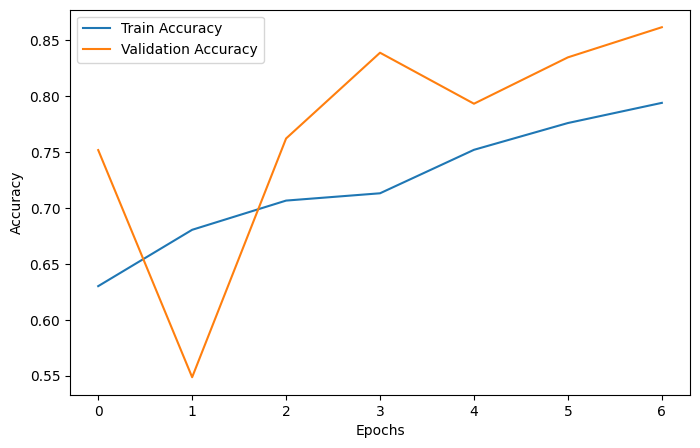

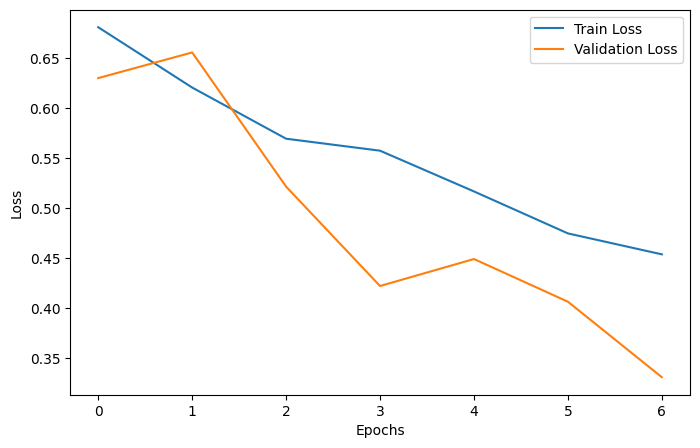

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
              precision    recall  f1-score   support

           0       0.90      0.48      0.62       662
           1       0.24      0.76      0.36       143

    accuracy                           0.53       805
   macro avg       0.57      0.62      0.49       805
weighted avg       0.79      0.53      0.58       805


 Training Time: 105.8 seconds,Test time: 1.3 seconds


In [74]:
plt.figure(figsize=(8,5))

plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')

plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()
start_time = time.time()
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
end_time = time.time()
temps_test = end_time - start_time
print(f"\n Training Time: {temps_app:.1f} seconds,Test time: {temps_test:.1f} seconds")

In [80]:
from sklearn.model_selection import GridSearchCV
model.pop()
model.summary()
print("Extraction des features du CNN...")
features_train, features_test = model.predict(X_train), model.predict(X_test)
base_svm = SVC(class_weight='balanced', random_state=42)

param_grid = {'kernel': ['rbf', 'poly'],'degree': [2, 3, 4],  'C': [0.1, 1, 10]     
}


print("\nRecherche des meilleurs hyperparamètres pour le SVM hybride...")
grid_search = GridSearchCV(estimator=base_svm, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(features_train, y_train)

print("\n OPTIMISATION TERMINÉE ")
print(f"Meilleurs paramètres trouvés : {grid_search.best_params_}")

best_svm_hybrid = grid_search.best_estimator_

print("\nTest du modèle hybride optimisé....")

y_pred = best_svm_hybrid.predict(features_test)

print(classification_report(y_test, y_pred, target_names=['Sain', 'Fracture']))

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)                   │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_31 (MaxPooling2D)      │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_32 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,701,060 (25.56 MB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,608,388 (25.21 MB)

Extraction des features du CNN...
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step

Recherche des meilleurs hyperparamètres pour le SVM hybride...

 OPTIMISATION TERMINÉE 
Meilleurs paramètres trouvés : {'C': 0.1, 'degree': 4, 'kernel': 'poly'}

Test du modèle hybride optimisé....
              precision    recall  f1-score   support

        Sain       0.87      0.83      0.85       662
    Fracture       0.35      0.43      0.39       143

    accuracy                           0.76       805
   macro avg       0.61      0.63      0.62       805
weighted avg       0.78      0.76      0.77       805

